In [3]:
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import numpy as np
import statistics as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math



We'd like to further test if the Champion teams have higher stats like Avg Points Allowed and other important features we captured using the model from the previous section.

# Raw Point differential analysis

In [4]:
data = pd.read_csv("nba_second_round_history_augmented.csv")

# Create derived difference features for Q2 and follow-up analyses
data["Average Points Difference"] = data["Average Points scored"] - data["Average Points allowed"]
data["eFG% Difference"] = data["eFG%"] - data["Opp eFG%"]
data["TOV% Difference"] = data["Opp TOV%"] - data["TOV%"]
data["ORB% Difference"] = data["ORB%"] - data["Opp ORB%"]
data["FT/FGA Difference"] = data["FT/FGA"] - data["Opp FT/FGA"]
data["TS% Difference"] = data["Team TS%"] - data["Opp TS%"]

print("Shape:", data.shape)
print("Seasons:", data["Season"].min(), "-", data["Season"].max())
print("Number of seasons:", data["Season"].nunique())
print("Champion counts:")
print(data["Champion"].value_counts())
data.head()

Shape: (168, 26)
Seasons: 1984 - 2025
Number of seasons: 42
Champion counts:
Champion
False    126
True      42
Name: count, dtype: int64


,Season,Team,Opponent,Games played,Average Points scored,Average Points allowed,Offensive Rating,Defensive Rating,eFG%,Opp eFG%,...,Champion,Actual Wins (%),Team TS%,Opp TS%,Average Points Difference,eFG% Difference,TOV% Difference,ORB% Difference,FT/FGA Difference,TS% Difference
0,1984,BOS,NYK,7,111.0,103.0,113.9,105.7,49.8,48.4,...,True,57.143,54.9350,53.9574,8.0,1.4,1.8,3.7,-1.1,0.9776
1,1984,MIL,NJN,6,98.2,96.3,102.8,100.9,47.1,40.5,...,False,66.667,54.0129,47.1452,1.9,6.6,-6.1,-2.9,3.3,6.8677
2,1984,LAL,DAL,5,120.6,106.2,121.9,107.4,57.0,45.4,...,False,80.000,59.7550,50.4063,14.4,11.6,-0.9,2.7,-3.2,9.3487
3,1984,PHO,UTA,6,103.7,101.0,107.0,104.3,46.2,46.8,...,False,66.667,51.2187,52.6627,2.7,-0.6,2.4,1.5,-7.0,-1.4440
4,1985,BOS,DET,6,120.5,112.7,118.1,110.4,51.9,47.8,...,False,66.667,57.8882,51.6914,7.8,4.1,-2.2,1.4,10.6,6.1968


# descripitive

In [5]:
# descriptive 
champs = data[data["Champion"] == True]
non_champs = data[data["Champion"] == False]
point_diff_champ = champs["Average Points Difference"].dropna()
point_diff_non_champ = non_champs["Average Points Difference"].dropna()

desc_q2 = pd.DataFrame({
    "Group": ["Champion", "Non-Champion"],
    "n": [len(point_diff_champ), len(point_diff_non_champ)],
    "Mean": [point_diff_champ.mean(), point_diff_non_champ.mean()],
    "SD": [point_diff_champ.std(ddof=1), point_diff_non_champ.std(ddof=1)],
    "Median": [point_diff_champ.median(), point_diff_non_champ.median()],
    "Min": [point_diff_champ.min(), point_diff_non_champ.min()],
    "Max": [point_diff_champ.max(), point_diff_non_champ.max()]
})

desc_q2

,Group,n,Mean,SD,Median,Min,Max
0,Champion,42,7.207143,4.214168,7.7,-2.8,15.0
1,Non-Champion,126,4.859524,4.695771,4.1,-3.2,25.3


## Normality check for raw APD

In [6]:
raw_shapiro_champ = stats.shapiro(point_diff_champ)
raw_shapiro_non_champ = stats.shapiro(point_diff_non_champ)

print("Raw APD Shapiro-Wilk test")
print("Champion group:")
print("Statistic:", raw_shapiro_champ.statistic)
print("p-value:", raw_shapiro_champ.pvalue)

print("\nNon-champion group:")
print("Statistic:", raw_shapiro_non_champ.statistic)
print("p-value:", raw_shapiro_non_champ.pvalue)

Raw APD Shapiro-Wilk test
Champion group:
Statistic: 0.9666741642490541
p-value: 0.2542653091201496

Non-champion group:
Statistic: 0.9401146380736857
p-value: 2.8262887709043174e-05


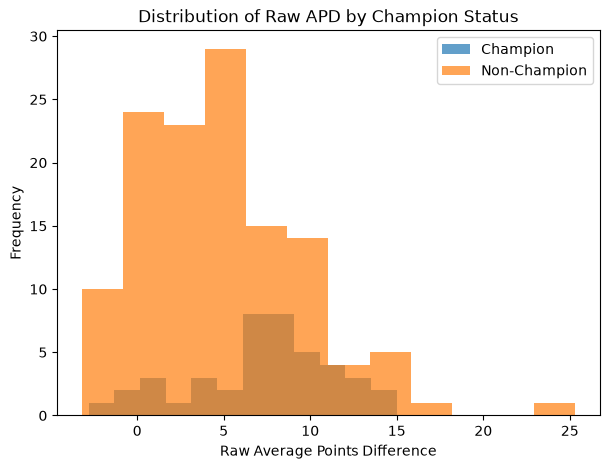

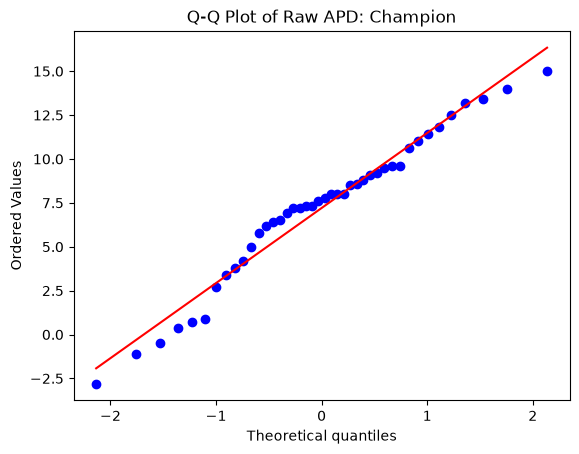

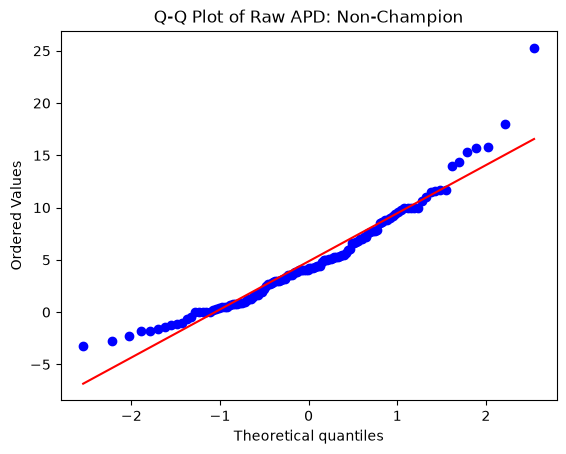

In [7]:
# Normality plots for raw APD

plt.figure(figsize=(7, 5))
plt.hist(point_diff_champ, bins=12, alpha=0.7, label="Champion")
plt.hist(point_diff_non_champ, bins=12, alpha=0.7, label="Non-Champion")
plt.xlabel("Raw Average Points Difference")
plt.ylabel("Frequency")
plt.title("Distribution of Raw APD by Champion Status")
plt.legend()
plt.show()

stats.probplot(point_diff_champ, dist="norm", plot=plt)
plt.title("Q-Q Plot of Raw APD: Champion")
plt.show()

stats.probplot(point_diff_non_champ, dist="norm", plot=plt)
plt.title("Q-Q Plot of Raw APD: Non-Champion")
plt.show()

# F test (the F-test does not show a significant difference in variances)

In [8]:
var_champ = point_diff_champ.var(ddof=1)
var_non_champ = point_diff_non_champ.var(ddof=1)

#  bigger var at numerator
if var_champ >= var_non_champ:
    F = var_champ / var_non_champ
    df1 = len(point_diff_champ) - 1
    df2 = len(point_diff_non_champ) - 1
else:
    F = var_non_champ / var_champ
    df1 = len(point_diff_non_champ) - 1
    df2 = len(point_diff_champ) - 1

p_one_tail = 1 - stats.f.cdf(F, df1, df2)
p_two_tail = 2 * p_one_tail

print("Champion variance:", var_champ)
print("Non-champion variance:", var_non_champ)
print("F statistic:", F)
print("df1:", df1, "df2:", df2)
print("Two-sided p-value:", p_two_tail)

Champion variance: 17.75921602787456
Non-champion variance: 22.050268571428564
F statistic: 1.241623984798588
df1: 125 df2: 41
Two-sided p-value: 0.43034568928689754


# Welch's t-test (Welch’s t-test shows that this difference is statistically significant.)

In [9]:
# Welch's two sample t-test
welch_result = stats.ttest_ind(
    point_diff_champ,
    point_diff_non_champ,
    equal_var=False,
    alternative="greater"
)

print("Welch's t-test")
print("t-statistic:", welch_result.statistic)
print("p-value:", welch_result.pvalue)

Welch's t-test
t-statistic: 3.0362317608811593
p-value: 0.0016303372112370744


# Pooled t-test (Pooled t-test also show significance difference)

In [10]:
# Pooled two sample t-test
pooled_result = stats.ttest_ind(
    point_diff_champ,
    point_diff_non_champ,
    equal_var=True,
    alternative="greater"
)

print("Pooled two sample t-test")
print("t-statistic:", pooled_result.statistic)
print("p-value:", pooled_result.pvalue)

Pooled two sample t-test
t-statistic: 2.8758897352045105
p-value: 0.002278797526796934


# two sample Z-test

In [11]:
mean_champ = point_diff_champ.mean()
mean_non_champ = point_diff_non_champ.mean()

s_champ = point_diff_champ.std(ddof=1)
s_non_champ = point_diff_non_champ.std(ddof=1)

n_champ = len(point_diff_champ)
n_non_champ = len(point_diff_non_champ)

z_stat = (mean_champ - mean_non_champ) / np.sqrt(
    s_champ**2 / n_champ + s_non_champ**2 / n_non_champ
)

p_value_z = 1 - stats.norm.cdf(z_stat)

print("Large-sample z-test approximation")
print("z-statistic:", z_stat)
print("p-value:", p_value_z)

Large-sample z-test approximation
z-statistic: 3.0362317608811593
p-value: 0.0011977757637097186


# Addional: Cohen's d 

In [12]:
# Cohen's d effect size
n1 = len(point_diff_champ)
n2 = len(point_diff_non_champ)

s1 = point_diff_champ.std(ddof=1)
s2 = point_diff_non_champ.std(ddof=1)

pooled_sd = np.sqrt(
    ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
)

cohen_d = (point_diff_champ.mean() - point_diff_non_champ.mean()) / pooled_sd

print("Cohen's d:", cohen_d)

Cohen's d: 0.5124092414893004


# Additional： Mann-Whitney U test

In [13]:
u_result_raw = stats.mannwhitneyu(
    point_diff_champ,
    point_diff_non_champ,
    alternative="greater"
)

print("Raw APD Mann-Whitney U test")
print("U statistic:", u_result_raw.statistic)
print("p-value:", u_result_raw.pvalue)

Raw APD Mann-Whitney U test
U statistic: 3560.5
p-value: 0.0004065276745149552


# Summary

In [14]:
summary_q2 = pd.DataFrame({
    "Test": [
        "F-test for equal variances",
        "Welch's t-test",
        "Pooled two-sample t-test",
        "Large-sample z approximation",
        "Mann-Whitney U test",
        "Cohen's d"
    ],
    "Statistic": [
        F,
        welch_result.statistic,
        pooled_result.statistic,
        z_stat,
        u_result_raw.statistic,
        cohen_d
    ],
    "p-value": [
        p_two_tail,
        welch_result.pvalue,
        pooled_result.pvalue,
        p_value_z,
        u_result_raw.pvalue,
        np.nan
    ],
    "Role": [
        "Diagnostic check for equal variances",
        "Main test for mean difference",
        "Robustness check assuming equal variances",
        "Large-sample approximation",
        "Non-parametric robustness check",
        "Effect size for practical difference"
    ]
})

summary_q2

,Test,Statistic,p-value,Role
0,F-test for equal variances,1.241624,0.430346,Diagnostic check for equal variances
1,Welch's t-test,3.036232,0.001630,Main test for mean difference
2,Pooled two-sample t-test,2.875890,0.002279,Robustness check assuming equal variances
3,Large-sample z approximation,3.036232,0.001198,Large-sample approximation
4,Mann-Whitney U test,3560.500000,0.000407,Non-parametric robustness check
5,Cohen's d,0.512409,NaN,Effect size for practical difference


<Figure size 700x500 with 0 Axes>

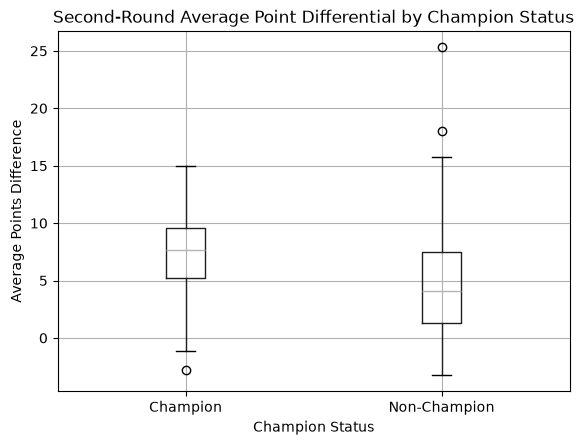

In [15]:
plot_data = data.copy()
plot_data["Champion Status"] = plot_data["Champion"].map({
    False: "Non-Champion",
    True: "Champion"
})
plt.figure(figsize=(7, 5))
plot_data.boxplot(column="Average Points Difference", by="Champion Status")
plt.title("Second-Round Average Point Differential by Champion Status")
plt.suptitle("")
plt.xlabel("Champion Status")
plt.ylabel("Average Points Difference")
plt.show()

# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

# Era-adjusted standardized Q2 analysis

In [16]:
standardized_data = pd.read_csv("nba_second_round_history_standardised.csv")
print("Shape:", standardized_data.shape)
print("Seasons:", standardized_data["Season"].min(), "-", standardized_data["Season"].max())
print("Champion counts:")
print(standardized_data["Champion"].value_counts())
standardized_data.head()

Shape: (168, 21)
Seasons: 1984 - 2025
Champion counts:
Champion
False    126
True      42
Name: count, dtype: int64


,Season,Games played,Champion,Average Points scored,Average Points allowed,Offensive Rating,Defensive Rating,Team TS%,eFG%,TOV%,...,FT/FGA,Opp eFG%,Opp TOV%,Opp FT/FGA,Net Rating,Average Points Difference,eFG% Difference,TOV% Difference,ORB% Difference,FT/FGA Difference
0,1984,7,True,0.060,-1.093,2.330,-0.546,0.140,-0.091,-0.624,...,1.101,-0.554,0.667,1.862,2.613,2.511,0.362,-1.266,1.319,-0.234
1,1984,6,False,-2.240,-2.283,-2.431,-2.572,-0.665,-2.058,2.731,...,5.349,-5.555,-2.292,3.855,0.165,0.148,2.873,4.912,-0.902,-0.220
2,1984,5,False,1.785,-0.524,5.761,0.171,4.344,5.154,-1.770,...,-3.002,-2.453,-2.526,-1.036,5.062,4.991,5.288,0.846,0.982,-0.240
3,1984,6,False,-1.252,-1.448,-0.630,-1.137,-3.102,-2.713,-1.688,...,-1.554,-1.567,0.122,2.043,0.476,0.458,-0.604,-1.735,0.578,-0.252
4,1985,6,False,2.059,0.796,2.937,1.802,1.839,1.076,-0.804,...,1.605,-1.074,-3.191,-2.132,1.895,1.878,1.469,1.541,0.300,-0.092


In [17]:
std_champs = standardized_data[standardized_data["Champion"] == True]
std_non_champs = standardized_data[standardized_data["Champion"] == False]

std_point_diff_champ = std_champs["Average Points Difference"].dropna()
std_point_diff_non_champ = std_non_champs["Average Points Difference"].dropna()

print("Champion n:", len(std_point_diff_champ))
print("Non-champion n:", len(std_point_diff_non_champ))

Champion n: 42
Non-champion n: 126


## descripitive

In [18]:
desc_q2_standardized = pd.DataFrame({
    "Group": ["Champion", "Non-Champion"],
    "n": [len(std_point_diff_champ), len(std_point_diff_non_champ)],
    "Mean": [std_point_diff_champ.mean(), std_point_diff_non_champ.mean()],
    "SD": [std_point_diff_champ.std(ddof=1), std_point_diff_non_champ.std(ddof=1)],
    "Median": [std_point_diff_champ.median(), std_point_diff_non_champ.median()],
    "Min": [std_point_diff_champ.min(), std_point_diff_non_champ.min()],
    "Max": [std_point_diff_champ.max(), std_point_diff_non_champ.max()]
})

desc_q2_standardized

,Group,n,Mean,SD,Median,Min,Max
0,Champion,42,1.441000,1.502515,1.530,-2.208,3.816
1,Non-Champion,126,0.642206,1.821581,0.379,-2.722,9.948


## Normality check for standardized APD

In [19]:
std_shapiro_champ = stats.shapiro(std_point_diff_champ)
std_shapiro_non_champ = stats.shapiro(std_point_diff_non_champ)

print("Standardized APD Shapiro-Wilk test")
print("Champion group:")
print("Statistic:", std_shapiro_champ.statistic)
print("p-value:", std_shapiro_champ.pvalue)

print("\nNon-champion group:")
print("Statistic:", std_shapiro_non_champ.statistic)
print("p-value:", std_shapiro_non_champ.pvalue)

Standardized APD Shapiro-Wilk test
Champion group:
Statistic: 0.9620625613138293
p-value: 0.1749777119893624

Non-champion group:
Statistic: 0.9169908072652906
p-value: 9.664659368775662e-07


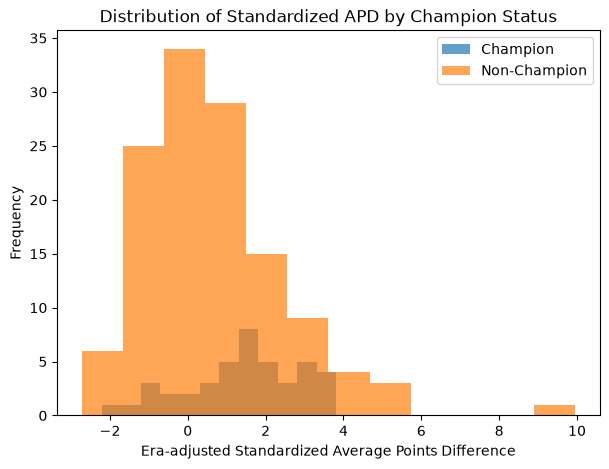

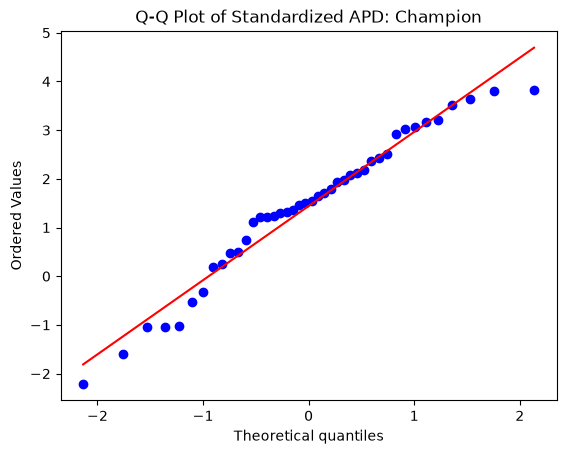

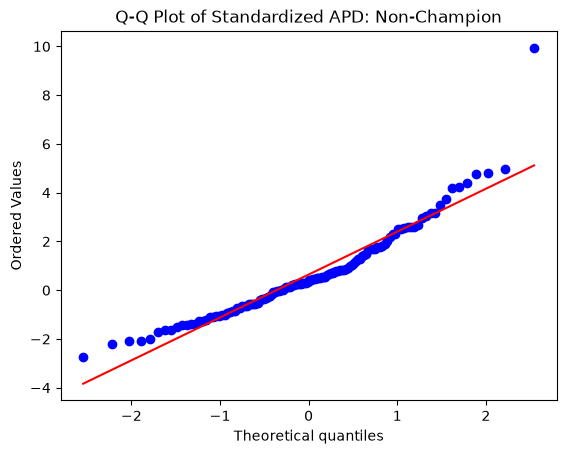

In [20]:
# Normality plots for standardized APD

plt.figure(figsize=(7, 5))
plt.hist(std_point_diff_champ, bins=12, alpha=0.7, label="Champion")
plt.hist(std_point_diff_non_champ, bins=12, alpha=0.7, label="Non-Champion")
plt.xlabel("Era-adjusted Standardized Average Points Difference")
plt.ylabel("Frequency")
plt.title("Distribution of Standardized APD by Champion Status")
plt.legend()
plt.show()

stats.probplot(std_point_diff_champ, dist="norm", plot=plt)
plt.title("Q-Q Plot of Standardized APD: Champion")
plt.show()

stats.probplot(std_point_diff_non_champ, dist="norm", plot=plt)
plt.title("Q-Q Plot of Standardized APD: Non-Champion")
plt.show()

## F-test

In [21]:
std_var_champ = std_point_diff_champ.var(ddof=1)
std_var_non_champ = std_point_diff_non_champ.var(ddof=1)

if std_var_champ >= std_var_non_champ:
    std_F = std_var_champ / std_var_non_champ
    std_df1 = len(std_point_diff_champ) - 1
    std_df2 = len(std_point_diff_non_champ) - 1
else:
    std_F = std_var_non_champ / std_var_champ
    std_df1 = len(std_point_diff_non_champ) - 1
    std_df2 = len(std_point_diff_champ) - 1

std_p_one_tail = 1 - stats.f.cdf(std_F, std_df1, std_df2)
std_p_two_tail = 2 * std_p_one_tail

print("Champion variance:", std_var_champ)
print("Non-champion variance:", std_var_non_champ)
print("F statistic:", std_F)
print("df1:", std_df1, "df2:", std_df2)
print("Two-sided p-value:", std_p_two_tail)

Champion variance: 2.257551268292683
Non-champion variance: 3.318157029079366
F statistic: 1.4698036211548748
df1: 125 df2: 41
Two-sided p-value: 0.1572175699575704


## Welch t-test

In [22]:
std_welch_result = stats.ttest_ind(
    std_point_diff_champ,
    std_point_diff_non_champ,
    equal_var=False,
    alternative="greater"
)

print("Welch's t-test on standardized average point differential")
print("t-statistic:", std_welch_result.statistic)
print("p-value:", std_welch_result.pvalue)

Welch's t-test on standardized average point differential
t-statistic: 2.8226487916869836
p-value: 0.002969616531161952


## Pooled t-test

In [23]:
std_pooled_result = stats.ttest_ind(
    std_point_diff_champ,
    std_point_diff_non_champ,
    equal_var=True,
    alternative="greater"
)

print("Pooled t-test on standardized average point differential")
print("t-statistic:", std_pooled_result.statistic)
print("p-value:", std_pooled_result.pvalue)

Pooled t-test on standardized average point differential
t-statistic: 2.564478027148089
p-value: 0.005609541749887134


## z-test 

In [24]:
std_mean_champ = std_point_diff_champ.mean()
std_mean_non_champ = std_point_diff_non_champ.mean()

std_s_champ = std_point_diff_champ.std(ddof=1)
std_s_non_champ = std_point_diff_non_champ.std(ddof=1)

std_n_champ = len(std_point_diff_champ)
std_n_non_champ = len(std_point_diff_non_champ)

std_z_stat = (std_mean_champ - std_mean_non_champ) / np.sqrt(
    std_s_champ**2 / std_n_champ
    + std_s_non_champ**2 / std_n_non_champ
)

std_p_value_z = 1 - stats.norm.cdf(std_z_stat)

print("Large-sample z-test approximation on standardized average point differential")
print("z-statistic:", std_z_stat)
print("p-value:", std_p_value_z)

Large-sample z-test approximation on standardized average point differential
z-statistic: 2.8226487916869836
p-value: 0.0023814357685184584


## Cohen's d

In [25]:
std_n1 = len(std_point_diff_champ)
std_n2 = len(std_point_diff_non_champ)

std_s1 = std_point_diff_champ.std(ddof=1)
std_s2 = std_point_diff_non_champ.std(ddof=1)

std_pooled_sd = np.sqrt(
    ((std_n1 - 1) * std_s1**2 + (std_n2 - 1) * std_s2**2)
    / (std_n1 + std_n2 - 2)
)

std_cohen_d = (
    std_point_diff_champ.mean() - std_point_diff_non_champ.mean()
) / std_pooled_sd

print("Cohen's d:", std_cohen_d)

Cohen's d: 0.45692372159514805


## Mann–Whitney U test

In [26]:
u_result_std = stats.mannwhitneyu(
    std_point_diff_champ,
    std_point_diff_non_champ,
    alternative="greater"
)

print("Standardized APD Mann-Whitney U test")
print("U statistic:", u_result_std.statistic)
print("p-value:", u_result_std.pvalue)

Standardized APD Mann-Whitney U test
U statistic: 3544.5
p-value: 0.0005020355067765911


## summary

In [27]:
summary_q2_standardized = pd.DataFrame({
    "Test": [
        "F-test for equal variances",
        "Welch's t-test",
        "Pooled two-sample t-test",
        "Large-sample z approximation",
        "Mann-Whitney U test",
        "Cohen's d"
    ],
    "Statistic": [
        std_F,
        std_welch_result.statistic,
        std_pooled_result.statistic,
        std_z_stat,
        u_result_std.statistic,
        std_cohen_d
    ],
    "p-value": [
        std_p_two_tail,
        std_welch_result.pvalue,
        std_pooled_result.pvalue,
        std_p_value_z,
        u_result_std.pvalue,
        np.nan
    ],
    "Role": [
        "Diagnostic check for equal variances",
        "Main test for standardized mean difference",
        "Robustness check assuming equal variances",
        "Large-sample approximation",
        "Non-parametric robustness check",
        "Effect size for practical difference"
    ]
})

summary_q2_standardized

,Test,Statistic,p-value,Role
0,F-test for equal variances,1.469804,0.157218,Diagnostic check for equal variances
1,Welch's t-test,2.822649,0.002970,Main test for standardized mean difference
2,Pooled two-sample t-test,2.564478,0.005610,Robustness check assuming equal variances
3,Large-sample z approximation,2.822649,0.002381,Large-sample approximation
4,Mann-Whitney U test,3544.500000,0.000502,Non-parametric robustness check
5,Cohen's d,0.456924,NaN,Effect size for practical difference


# –––––––––––––––––––––––––––––––––––––––-–––––––––––––––––––––––––––––––––––––––-–––––––––––––––––––––––––––––––––––––––-–––––––––––––––––––––––––––––––––––––––-––––––––––––––––––––––––––––––––––––

# Season standardized point differential analysis

In [28]:
# Season-normalized average point differential
data["Season Normalized Average Points Difference"] = data.groupby("Season")["Average Points Difference"].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)

data[[
    "Season",
    "Team",
    "Champion",
    "Average Points Difference",
    "Season Normalized Average Points Difference"
]].head(12)

,Season,Team,Champion,Average Points Difference,Season Normalized Average Points Difference
0,1984,BOS,True,8.0,0.216496
1,1984,MIL,False,1.9,-0.840003
2,1984,LAL,False,14.4,1.324953
3,1984,PHO,False,2.7,-0.701446
4,1985,BOS,False,7.8,-0.668043
5,1985,PHI,False,10.0,0.556702
6,1985,DEN,False,7.2,-1.002064
7,1985,LAL,True,11.0,1.113404
8,1986,BOS,True,9.6,0.835122
9,1986,MIL,False,-0.7,-1.356409


## descripitive

In [29]:
season_norm_champ = data[data["Champion"] == True]["Season Normalized Average Points Difference"].dropna()
season_norm_non_champ = data[data["Champion"] == False]["Season Normalized Average Points Difference"].dropna()

desc_q2_season_norm = pd.DataFrame({
    "Group": ["Champion", "Non-Champion"],
    "n": [len(season_norm_champ), len(season_norm_non_champ)],
    "Mean": [season_norm_champ.mean(), season_norm_non_champ.mean()],
    "SD": [season_norm_champ.std(ddof=1), season_norm_non_champ.std(ddof=1)],
    "Median": [season_norm_champ.median(), season_norm_non_champ.median()],
    "Min": [season_norm_champ.min(), season_norm_non_champ.min()],
    "Max": [season_norm_champ.max(), season_norm_non_champ.max()]
})

desc_q2_season_norm

,Group,n,Mean,SD,Median,Min,Max
0,Champion,42,0.374382,0.822356,0.552614,-1.386668,1.495125
1,Non-Champion,126,-0.124794,0.850524,-0.240624,-1.471160,1.489850


## Normality check for season-normalized APD

In [30]:
season_norm_shapiro_champ = stats.shapiro(season_norm_champ)
season_norm_shapiro_non_champ = stats.shapiro(season_norm_non_champ)

print("Season-normalized APD Shapiro-Wilk test")
print("Champion group:")
print("Statistic:", season_norm_shapiro_champ.statistic)
print("p-value:", season_norm_shapiro_champ.pvalue)

print("\nNon-champion group:")
print("Statistic:", season_norm_shapiro_non_champ.statistic)
print("p-value:", season_norm_shapiro_non_champ.pvalue)

Season-normalized APD Shapiro-Wilk test
Champion group:
Statistic: 0.9389386576298512
p-value: 0.026238084001584346

Non-champion group:
Statistic: 0.9524441882789149
p-value: 0.00022486674059219274


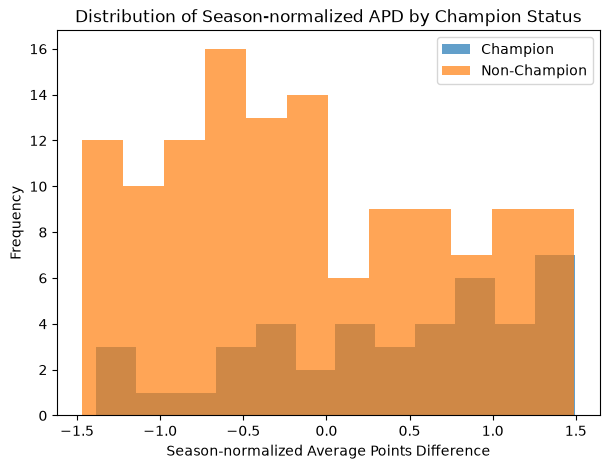

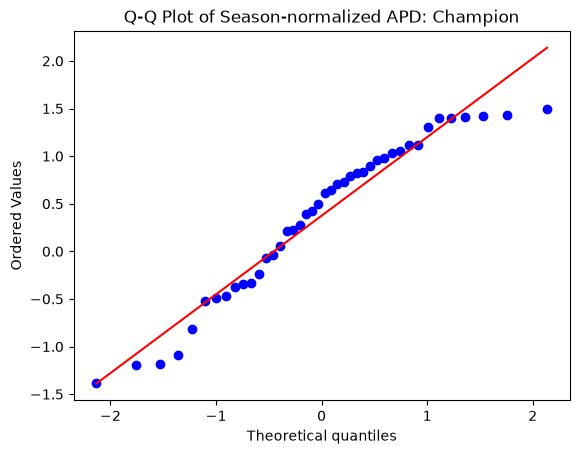

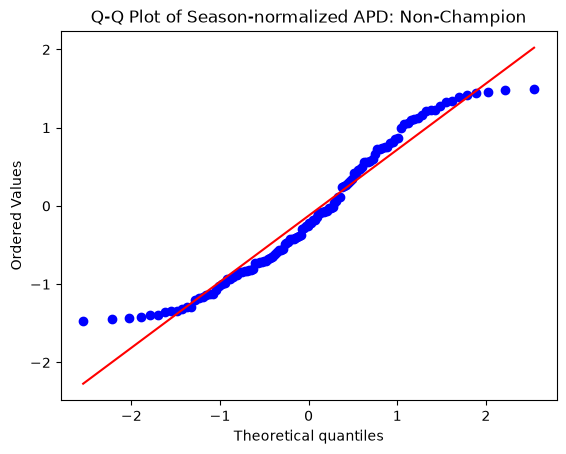

In [31]:
# Normality plots for season-normalized APD

plt.figure(figsize=(7, 5))
plt.hist(season_norm_champ, bins=12, alpha=0.7, label="Champion")
plt.hist(season_norm_non_champ, bins=12, alpha=0.7, label="Non-Champion")
plt.xlabel("Season-normalized Average Points Difference")
plt.ylabel("Frequency")
plt.title("Distribution of Season-normalized APD by Champion Status")
plt.legend()
plt.show()

stats.probplot(season_norm_champ, dist="norm", plot=plt)
plt.title("Q-Q Plot of Season-normalized APD: Champion")
plt.show()

stats.probplot(season_norm_non_champ, dist="norm", plot=plt)
plt.title("Q-Q Plot of Season-normalized APD: Non-Champion")
plt.show()

## F-test

In [32]:
season_norm_var_champ = season_norm_champ.var(ddof=1)
season_norm_var_non_champ = season_norm_non_champ.var(ddof=1)

if season_norm_var_champ >= season_norm_var_non_champ:
    season_norm_F = season_norm_var_champ / season_norm_var_non_champ
    season_norm_df1 = len(season_norm_champ) - 1
    season_norm_df2 = len(season_norm_non_champ) - 1
else:
    season_norm_F = season_norm_var_non_champ / season_norm_var_champ
    season_norm_df1 = len(season_norm_non_champ) - 1
    season_norm_df2 = len(season_norm_champ) - 1

season_norm_p_one_tail = 1 - stats.f.cdf(season_norm_F, season_norm_df1, season_norm_df2)
season_norm_p_two_tail = 2 * season_norm_p_one_tail

print("Champion variance:", season_norm_var_champ)
print("Non-champion variance:", season_norm_var_non_champ)
print("F statistic:", season_norm_F)
print("df1:", season_norm_df1, "df2:", season_norm_df2)
print("Two-sided p-value:", season_norm_p_two_tail)

Champion variance: 0.6762690310865019
Non-champion variance: 0.7233912501972689
F statistic: 1.0696796939452629
df1: 125 df2: 41
Two-sided p-value: 0.8264896070443826


## Welch's t-test

In [33]:
season_norm_welch_result = stats.ttest_ind(
    season_norm_champ,
    season_norm_non_champ,
    equal_var=False,
    alternative="greater"
)

print("Welch's t-test on season-normalized point differential")
print("t-statistic:", season_norm_welch_result.statistic)
print("p-value:", season_norm_welch_result.pvalue)

Welch's t-test on season-normalized point differential
t-statistic: 3.377528723243446
p-value: 0.0005898767098949815


## Pooled t-test

In [34]:
season_norm_pooled_result = stats.ttest_ind(
    season_norm_champ,
    season_norm_non_champ,
    equal_var=True,
    alternative="greater"
)

print("Pooled t-test on season-normalized point differential")
print("t-statistic:", season_norm_pooled_result.statistic)
print("p-value:", season_norm_pooled_result.pvalue)

Pooled t-test on season-normalized point differential
t-statistic: 3.320812687980807
p-value: 0.0005518409602031681


## z-test (n > 40)

In [35]:
season_norm_mean_champ = season_norm_champ.mean()
season_norm_mean_non_champ = season_norm_non_champ.mean()

season_norm_s_champ = season_norm_champ.std(ddof=1)
season_norm_s_non_champ = season_norm_non_champ.std(ddof=1)

season_norm_n_champ = len(season_norm_champ)
season_norm_n_non_champ = len(season_norm_non_champ)

season_norm_z_stat = (season_norm_mean_champ - season_norm_mean_non_champ) / np.sqrt(
    season_norm_s_champ**2 / season_norm_n_champ
    + season_norm_s_non_champ**2 / season_norm_n_non_champ
)

season_norm_p_value_z = 1 - stats.norm.cdf(season_norm_z_stat)

print("Large-sample z-test approximation on season-normalized point differential")
print("z-statistic:", season_norm_z_stat)
print("p-value:", season_norm_p_value_z)

Large-sample z-test approximation on season-normalized point differential
z-statistic: 3.377528723243446
p-value: 0.0003657015698211863


## Cohen's d

In [36]:
season_norm_n1 = len(season_norm_champ)
season_norm_n2 = len(season_norm_non_champ)

season_norm_s1 = season_norm_champ.std(ddof=1)
season_norm_s2 = season_norm_non_champ.std(ddof=1)

season_norm_pooled_sd = np.sqrt(
    ((season_norm_n1 - 1) * season_norm_s1**2 + (season_norm_n2 - 1) * season_norm_s2**2)
    / (season_norm_n1 + season_norm_n2 - 2)
)

season_norm_cohen_d = (
    season_norm_champ.mean() - season_norm_non_champ.mean()
) / season_norm_pooled_sd

print("Cohen's d:", season_norm_cohen_d)

Cohen's d: 0.5916830154321912


#  Mann-Whitney U test

In [37]:
u_result_season_norm = stats.mannwhitneyu(
    season_norm_champ,
    season_norm_non_champ,
    alternative="greater"
)

print("Season-normalized APD Mann-Whitney U test")
print("U statistic:", u_result_season_norm.statistic)
print("p-value:", u_result_season_norm.pvalue)

Season-normalized APD Mann-Whitney U test
U statistic: 3522.5
p-value: 0.0006664571306225399


## summary

In [38]:
summary_q2_season_norm = pd.DataFrame({
    "Test": [
        "F-test for equal variances",
        "Welch's t-test",
        "Pooled two-sample t-test",
        "Large-sample z approximation",
        "Mann-Whitney U test",
        "Cohen's d"
    ],
    "Statistic": [
        season_norm_F,
        season_norm_welch_result.statistic,
        season_norm_pooled_result.statistic,
        season_norm_z_stat,
        u_result_season_norm.statistic,
        season_norm_cohen_d
    ],
    "p-value": [
        season_norm_p_two_tail,
        season_norm_welch_result.pvalue,
        season_norm_pooled_result.pvalue,
        season_norm_p_value_z,
        u_result_season_norm.pvalue,
        np.nan
    ],
    "Role": [
        "Diagnostic check for equal variances",
        "Main test for season-normalized mean difference",
        "Robustness check assuming equal variances",
        "Large-sample approximation",
        "Non-parametric robustness check",
        "Effect size for practical difference"
    ]
})

summary_q2_season_norm

,Test,Statistic,p-value,Role
0,F-test for equal variances,1.069680,0.826490,Diagnostic check for equal variances
1,Welch's t-test,3.377529,0.000590,Main test for season-normalized mean difference
2,Pooled two-sample t-test,3.320813,0.000552,Robustness check assuming equal variances
3,Large-sample z approximation,3.377529,0.000366,Large-sample approximation
4,Mann-Whitney U test,3522.500000,0.000666,Non-parametric robustness check
5,Cohen's d,0.591683,NaN,Effect size for practical difference


# –––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

# Extension: Follow-up Analysis on RF-Selected Important Features

In [39]:
standardized_data = pd.read_csv("nba_second_round_history_standardised.csv")

standardized_data.columns.tolist()

['Season',
 'Games played',
 'Champion',
 'Average Points scored',
 'Average Points allowed',
 'Offensive Rating',
 'Defensive Rating',
 'Team TS%',
 'eFG%',
 'TOV%',
 'ORB%',
 'FT/FGA',
 'Opp eFG%',
 'Opp TOV%',
 'Opp FT/FGA',
 'Net Rating',
 'Average Points Difference',
 'eFG% Difference',
 'TOV% Difference',
 'ORB% Difference',
 'FT/FGA Difference']

In [40]:
rf_selected_features = [
    "Offensive Rating",
    "Defensive Rating",
    "FT/FGA Difference",
    "Games played",
    "eFG% Difference",
    "Average Points Difference"
]

rf_feature_results = []

for feature in rf_selected_features:
    champ_values = standardized_data[standardized_data["Champion"] == True][feature].dropna()
    non_champ_values = standardized_data[standardized_data["Champion"] == False][feature].dropna()

    # Welch's t-test, two-sided because different features may have different "better" directions
    t_result = stats.ttest_ind(
        champ_values,
        non_champ_values,
        equal_var=False,
        alternative="two-sided"
    )

    # Cohen's d
    n1 = len(champ_values)
    n2 = len(non_champ_values)
    s1 = champ_values.std(ddof=1)
    s2 = non_champ_values.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
    cohen_d = (champ_values.mean() - non_champ_values.mean()) / pooled_sd

    rf_feature_results.append({
        "Feature": feature,
        "Champion Mean": champ_values.mean(),
        "Non-Champion Mean": non_champ_values.mean(),
        "Mean Difference": champ_values.mean() - non_champ_values.mean(),
        "Champion SD": champ_values.std(ddof=1),
        "Non-Champion SD": non_champ_values.std(ddof=1),
        "Welch t-statistic": t_result.statistic,
        "p-value": t_result.pvalue,
        "Cohen's d": cohen_d
    })

rf_feature_results_df = pd.DataFrame(rf_feature_results)
rf_feature_results_df.sort_values("p-value")

,Feature,Champion Mean,Non-Champion Mean,Mean Difference,Champion SD,Non-Champion SD,Welch t-statistic,p-value,Cohen's d
5,Average Points Difference,1.441000,0.642206,0.798794,1.502515,1.821581,2.822649,0.005939,0.456924
1,Defensive Rating,-0.782905,-0.079603,-0.703302,1.762084,2.358326,-2.046804,0.043480,-0.315954
4,eFG% Difference,1.108000,0.599341,0.508659,1.591468,1.910949,1.702294,0.092418,0.276864
3,Games played,5.500000,5.769841,-0.269841,1.087624,0.981123,-1.426063,0.158658,-0.267574
0,Offensive Rating,0.897857,0.593056,0.304802,2.145994,2.279434,0.784679,0.435140,0.135635
2,FT/FGA Difference,-0.293857,-0.288222,-0.005635,0.159600,0.150796,-0.200869,0.841409,-0.036825


<Figure size 700x500 with 0 Axes>

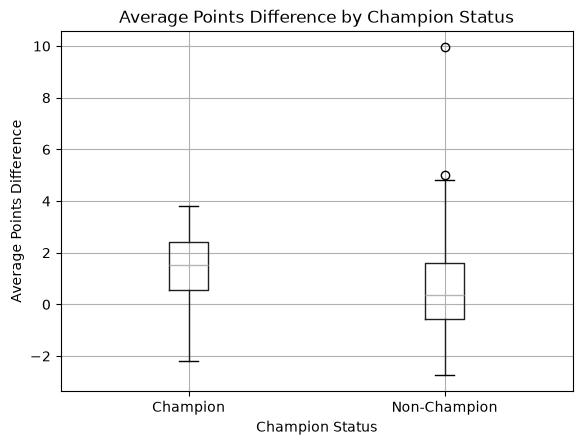

<Figure size 700x500 with 0 Axes>

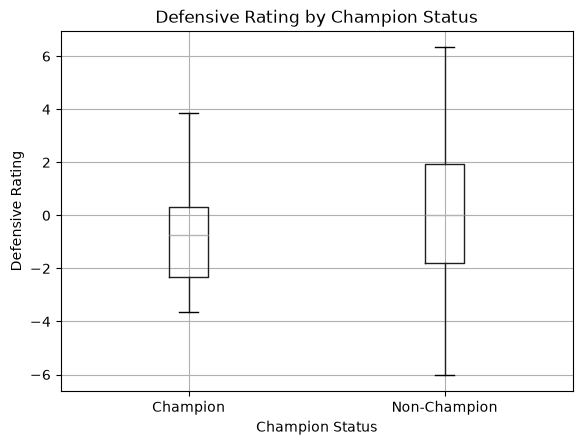

<Figure size 700x500 with 0 Axes>

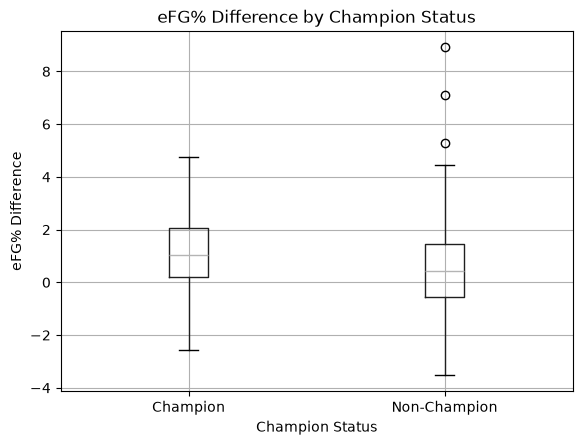

In [41]:
features_to_plot = [
    "Average Points Difference",
    "Defensive Rating",
    "eFG% Difference"
]

plot_data = standardized_data.copy()
plot_data["Champion Status"] = plot_data["Champion"].map({
    False: "Non-Champion",
    True: "Champion"
})

for feature in features_to_plot:
    plt.figure(figsize=(7, 5))
    plot_data.boxplot(column=feature, by="Champion Status")
    plt.title(f"{feature} by Champion Status")
    plt.suptitle("")
    plt.xlabel("Champion Status")
    plt.ylabel(feature)
    plt.show()

### Features to test: [Defensive Rating, Opp TOV%, FT/FGA,Offensive Rating]

In [43]:
features_to_test = [
    "Defensive Rating",
    "Opp TOV%",
    "FT/FGA",
    "Offensive Rating"
]

feature_followup_results = []

for feature in features_to_test:
    champ_values = data[data["Champion"] == True][feature].dropna()
    non_champ_values = data[data["Champion"] == False][feature].dropna()

    # Welch's t-test
    welch_result = stats.ttest_ind(
        champ_values,
        non_champ_values,
        equal_var=False,
        alternative="two-sided"
    )

    # Mann-Whitney U test
    mannwhitney_result = stats.mannwhitneyu(
        champ_values,
        non_champ_values,
        alternative="two-sided"
    )

    # Cohen's d
    n1 = len(champ_values)
    n2 = len(non_champ_values)
    s1 = champ_values.std(ddof=1)
    s2 = non_champ_values.std(ddof=1)

    pooled_sd = np.sqrt(
        ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
    )

    cohen_d = (champ_values.mean() - non_champ_values.mean()) / pooled_sd

    feature_followup_results.append({
        "Feature": feature,
        "Champion Mean": champ_values.mean(),
        "Non-Champion Mean": non_champ_values.mean(),
        "Mean Difference": champ_values.mean() - non_champ_values.mean(),
        "Champion SD": champ_values.std(ddof=1),
        "Non-Champion SD": non_champ_values.std(ddof=1),
        "Welch t-statistic": welch_result.statistic,
        "Welch p-value": welch_result.pvalue,
        "Mann-Whitney U statistic": mannwhitney_result.statistic,
        "Mann-Whitney p-value": mannwhitney_result.pvalue,
        "Cohen's d": cohen_d
    })

feature_followup_results_df = pd.DataFrame(feature_followup_results)

# Bonferroni correction 
feature_followup_results_df["Bonferroni-adjusted Welch p-value"] = np.minimum(
    feature_followup_results_df["Welch p-value"] * len(feature_followup_results_df),
    1.0
)

feature_followup_results_df.sort_values("Welch p-value")

,Feature,Champion Mean,Non-Champion Mean,Mean Difference,Champion SD,Non-Champion SD,Welch t-statistic,Welch p-value,Mann-Whitney U statistic,Mann-Whitney p-value,Cohen's d,Bonferroni-adjusted Welch p-value
2,FT/FGA,23.950000,25.894444,-1.944444,6.130860,5.464420,-1.827626,0.072260,2108.5,0.049170,-0.344983,0.289039
0,Defensive Rating,104.002381,105.757937,-1.755556,5.165339,6.437035,-1.787935,0.077276,2154.0,0.071788,-0.285574,0.309104
1,Opp TOV%,13.373810,12.878571,0.495238,2.134623,1.932319,1.332535,0.187347,3009.0,0.184128,0.249590,0.749386
3,Offensive Rating,111.823810,111.000000,0.823810,6.048374,6.736183,0.742458,0.460053,2867.0,0.419242,0.125332,1.000000
